<h2>LangGraph 101: Building Stateful AI Workflows</h2>


In this lab, you'll learn to build intelligent AI agents using LangGraph, a powerful Python framework for creating state-based workflows. You'll start by understanding LangGraph's core components and how they work together to create structured, decision-making systems. You'll learn how to define tasks as nodes, connect them using a graph structure, and create agents that can reason, plan, and act based on inputs. Through hands-on examples, you'll build two practical applications: an authentication workflow that validates user credentials with proper error handling and a question-answering system that responds to queries about LangGraph itself. By the end of this lab, you'll be able to create your own AI agents that can process information, make decisions, and adapt to changing conditions using both linear and cyclical workflows.


LangGraph doesn’t just manage tasks but also integrates the benefits of both DAGs (for structured flows) and cyclic graphs (for iterative workflows). This makes it a more versatile framework for designing intelligent, adaptable AI agents.

In [14]:
%pip install -q langgraph==0.2.57
%pip install langchain
%pip install langchain-ollama

Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain-ollama 1.1.0 requires langchain-core<2.0.0,>=1.2.21, but you have langchain-core 0.3.86 which is incompatible.

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached langchain-1.4.0-py3-none-any.whl.metadata (6.2 kB)
  Using cached langchain_core-1.6.2-py3-none-any.whl.metadata (4.8 kB)
  Using cached langgraph-1.2.11-py3-none-any.whl.metadata (4.9 kB)
  Using cached langgraph_checkpoint-4.2.0-py3-none-any.whl.metadata (6.7 kB)
  Using cached langgraph_prebuilt-1.1.0-py3-none-any.whl.metadata (5.2 kB)
  Using cached langgraph_sdk-0.4.4-py3-none-any.whl.metadata (5.1 kB)
  Using cached websockets-16.1.1-cp314-cp314-win_amd64.whl.metadata (7.0 kB)
Using cached langchain-1.4.0-py3-none-any.whl (161 kB)
Using cached langchain_core-1.6.2-py3-none-any.whl (571 kB)
Using cached langgraph-1.2.11-py3-none-any.whl (248 kB)
Using cached langgraph_checkpoint-4.2.0-py3-none-any.whl (56 kB)
Using cached langgraph_prebuilt-1.1.0-py3-none-any.whl (41 kB)
Using cached langgraph_sdk-0.4.4-py3-none-any.whl (162 kB)
Using cached websockets-16.1.1-cp314-cp314-win_amd64.whl (179 kB)

  Attempting uninstall: websockets

    Found existing installation: web


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
from langgraph.graph import StateGraph


d:\code\pythondemo\notebooks\agents\lang_graph\.venv\Lib\site-packages\langgraph\checkpoint\base\__init__.py:18: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


<h2>Components of LangGraph</h2>
LangGraph’s strength lies in its structured and intuitive design, composed of essential building blocks that enable the creation of intelligent AI agents, with default stages denoting start and end of workflow.

In this example, we are defining a state structure for a user authentication workflow. The state, called AuthState, is a typed dictionary that holds information about a user's credentials (username and password) and their authentication status (is_authenticated) as shown here:


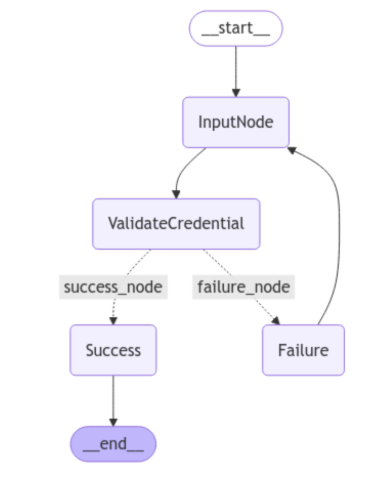


In [4]:
from typing import TypedDict, Optional

class AuthState(TypedDict):
    username: Optional[str] 
    password: Optional[str]
    is_authenticated: Optional[bool]
    output: Optional[str]

In [5]:
def input_node(state):
    print(state)
    if state.get('username', "") =="":
        username = input("What is your username?")

    password = input("Enter your password: ")
    
    if state.get('username', "") =="":
        return {"username":username, "password":password}
    else:
        return {"password": password}

In [6]:
auth_state_1: AuthState = {
    "username": "alice123",
    "password": "123",
    "is_authenticated": True,
    "output": "Login successful."
}
print(f"auth_state_1: {auth_state_1}")

input_node(auth_state_1)

auth_state_1: {'username': 'alice123', 'password': '123', 'is_authenticated': True, 'output': 'Login successful.'}
{'username': 'alice123', 'password': '123', 'is_authenticated': True, 'output': 'Login successful.'}


{'password': '123'}

In [7]:
auth_state_2: AuthState = {
    "username":"",
    "password": "wrongpassword",
    "is_authenticated": False,
    "output": "Authentication failed. Please try again."
}
print(f"auth_state_2: {auth_state_2}")

input_node(auth_state_2)

auth_state_2: {'username': '', 'password': 'wrongpassword', 'is_authenticated': False, 'output': 'Authentication failed. Please try again.'}
{'username': '', 'password': 'wrongpassword', 'is_authenticated': False, 'output': 'Authentication failed. Please try again.'}


{'username': '123', 'password': '123'}

In [8]:
def validate_credentials_node(state):
    # Extract username and password from the state
    username = state.get("username", "")
    password = state.get("password", "")

    print("Username :", username, "Password :", password)
    # Simulated credential validation
    if username == "test_user" and password == "secure_password":
        is_authenticated = True
    else:
        is_authenticated = False

    # Return the updated state with authentication result
    return {"is_authenticated": is_authenticated}

auth_state_3: AuthState = {
    "username":"test_user",
    "password":  "secure_password",
    "is_authenticated": False,
    "output": "Authentication failed. Please try again."
}
print(f"auth_state_3: {auth_state_3}")
validate_credentials_node(auth_state_3)

auth_state_3: {'username': 'test_user', 'password': 'secure_password', 'is_authenticated': False, 'output': 'Authentication failed. Please try again.'}
Username : test_user Password : secure_password


{'is_authenticated': True}

In [9]:
# Define the success node
def success_node(state):
    return {"output": "Authentication successful! Welcome."}

# Define the failure node
def failure_node(state):
    return {"output": "Not Successfull, please try again!"}

def router(state):
    if state['is_authenticated']:
        return "success_node"
    else:
        return "failure_node"

In [ ]:
from langgraph.graph import StateGraph
from langgraph.graph import END

# this will pop a input box at top of VS code. use secure_password as password to get success node. any other password will lead to repeated input box prompting password
# Create an instance of StateGraph with the GraphState structure
workflow = StateGraph(AuthState)
# workflow
workflow.add_node("InputNode", input_node)
workflow.add_node("ValidateCredential", validate_credentials_node)
workflow.add_node("Success", success_node)
workflow.add_node("Failure", failure_node)
workflow.add_edge("InputNode", "ValidateCredential")
workflow.add_edge("Success", END)
workflow.add_edge("Failure", "InputNode")
workflow.add_conditional_edges("ValidateCredential", router, {"success_node": "Success", "failure_node": "Failure"})
workflow.set_entry_point("InputNode")
app = workflow.compile()
inputs = {"username": "test_user"}
result = app.invoke(inputs)
print(result)
result['output']

{'username': 'test_user'}
Username : test_user Password : 123
{'username': 'test_user', 'password': '123', 'is_authenticated': False, 'output': 'Not Successfull, please try again!'}
Username : test_user Password : 123
{'username': 'test_user', 'password': '123', 'is_authenticated': False, 'output': 'Not Successfull, please try again!'}
Username : test_user Password : 123
{'username': 'test_user', 'password': '123', 'is_authenticated': False, 'output': 'Not Successfull, please try again!'}
Username : test_user Password : 
{'username': 'test_user', 'password': '', 'is_authenticated': False, 'output': 'Not Successfull, please try again!'}
Username : test_user Password : 
{'username': 'test_user', 'password': '', 'is_authenticated': False, 'output': 'Not Successfull, please try again!'}
Username : test_user Password : secure_password
{'username': 'test_user', 'password': 'secure_password', 'is_authenticated': True, 'output': 'Authentication successful! Welcome.'}


'Authentication successful! Welcome.'

<h2>Building a QA Workflow Specific to the Guided Project</h2>

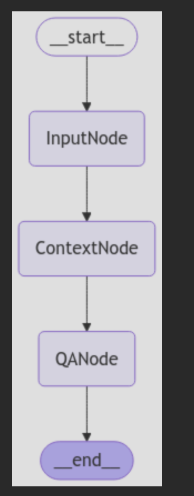


Now, we are designing a Question-Answering (QA) workflow specifically tailored for a guided project. This workflow leverages LangGraph to create modular, state-driven transitions and ensures that questions related to the guided project are prioritized and handled effectively.

The workflow evaluates whether a user’s query is relevant to the guided project (for example, what is this guided project about? or what is LangGraph?). For relevant questions, it uses predefined context to generate an informed response. If the query is unrelated to the guided project, the workflow explicitly communicate


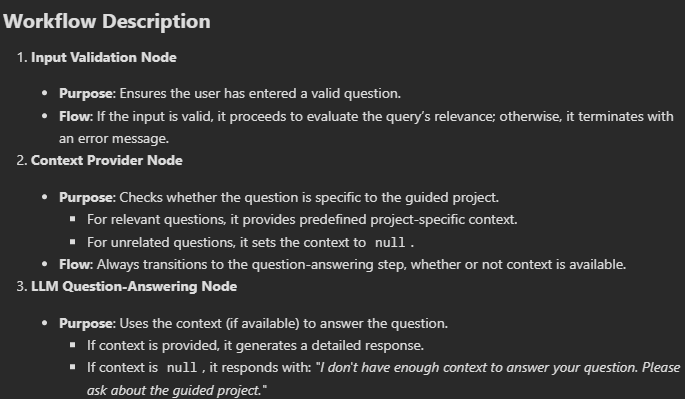

Defining the State for the QA Workflow

Now, we are defining the state for our Question-Answering (QA) workflow using the QAState TypedDict. This state will be used to store and manage the data as the workflow progresses, including the user's question, the relevant context (if any), and the generated answer.

This state structure will allow us to keep track of:

question: The user's input that will be evaluated to determine if it’s related to the guided project.
context: The context provided about the guided project, which will help the system generate a more relevant answer. If the question isn't related to the project, this will be None.
answer: The response generated by the LLM, which will depend on the context and the user's question.
In this case the context is :

This guided project is about using LangGraph, a Python library to design state-based workflows. LangGraph simplifies building complex applications by connecting modular nodes with conditional edges.

In [11]:
# Define the structure of the QA state
class QAState(TypedDict):
    # 'question' stores the user's input question. It can be a string or None if not provided.
    question: Optional[str]
    
    # 'context' stores relevant context about the guided project, if the question pertains to it.
    # If the question isn't related to the project, this will be None.
    context: Optional[str]
    
    # 'answer' stores the generated response or answer. It can be None until the answer is generated.
    answer: Optional[str]


# Create an example object
qa_state_example = QAState(
    question="What is the purpose of this guided project?",
    context="This project focuses on building a chatbot using Python.",
    answer=None
)

# Print the attributes
for key, value in qa_state_example.items():
    print(f"{key}: {value}")


def input_validation_node(state):
    # Extract the question from the state, and strip any leading or trailing spaces
    question = state.get("question", "").strip()
    
    # If the question is empty, return an error message indicating invalid input
    if not question:
        return {"valid": False, "error": "Question cannot be empty."}
    
    # If the question is valid, return valid status
    return {"valid": True}

input_validation_node(qa_state_example)



question: What is the purpose of this guided project?
context: This project focuses on building a chatbot using Python.
answer: None


{'valid': True}

In [12]:
def context_provider_node(state):
    question = state.get("question", "").lower()
    # Check if the question is related to the guided project
    if "langgraph" in question or "guided project" in question:
        context = (
            "This guided project is about using LangGraph, a Python library to design state-based workflows. "
            "LangGraph simplifies building complex applications by connecting modular nodes with conditional edges."
        )
        return {"context": context}
    # If unrelated, set context to null
    return {"context": None}

In [15]:
from langchain.chat_models import init_chat_model

llm = init_chat_model("gemma4", model_provider="ollama")

In [16]:
def llm_qa_node(state):
    # Extract the question and context from the state
    question = state.get("question", "")
    context = state.get("context", None)

    # Check for missing context and return a fallback response
    if not context:
        return {"answer": "I don't have enough context to answer your question."}

    # Construct the prompt dynamically
    prompt = f"Context: {context}\nQuestion: {question}\nAnswer the question based on the provided context."

    # Use LangChain's ChatOpenAI to get the response
    try:
        response = llm.invoke(prompt)
        return {"answer": response.content.strip()}
    except Exception as e:
        return {"answer": f"An error occurred: {str(e)}"}

In [19]:
qa_workflow = StateGraph(QAState)
qa_workflow.add_node("InputNode", input_validation_node)
qa_workflow.add_node("ContextNode", context_provider_node)
qa_workflow.add_node("QANode", llm_qa_node)
qa_workflow.set_entry_point("InputNode")
qa_workflow.add_edge("InputNode", "ContextNode")
qa_workflow.add_edge("ContextNode", "QANode")
qa_workflow.add_edge("QANode", END)
qa_app = qa_workflow.compile()
qa_app.invoke({"question": "What is the weather today?"})

{'question': 'What is the weather today?',
 'context': None,
 'answer': "I don't have enough context to answer your question."}

In [20]:
qa_app.invoke({"question": "What is LangGraph?"})


{'question': 'What is LangGraph?',
 'context': 'This guided project is about using LangGraph, a Python library to design state-based workflows. LangGraph simplifies building complex applications by connecting modular nodes with conditional edges.',
 'answer': 'LangGraph is a Python library used to design state-based workflows. It simplifies the process of building complex applications by allowing developers to connect modular nodes with conditional edges.'}

In [21]:

qa_app.invoke({"question": "What is the best guided project?"})

{'question': 'What is the best guided project?',
 'context': 'This guided project is about using LangGraph, a Python library to design state-based workflows. LangGraph simplifies building complex applications by connecting modular nodes with conditional edges.',
 'answer': 'Based only on the provided context, it is **impossible to determine** what the "best guided project" is.\n\nThe context only describes the nature of the project:\n*   **Topic:** Using LangGraph.\n*   **Goal:** Designing state-based workflows.\n*   **Method:** Connecting modular nodes with conditional edges.\n\nIf specific project options were provided, I could help you select the best one.'}